LISTA 5 É UM ÓTIMO EXEMPLO DE USO DE REGRESSÕES LINEARES E POLINOMAIS!!!!!!

MSE Linear: 0.7324840508469889


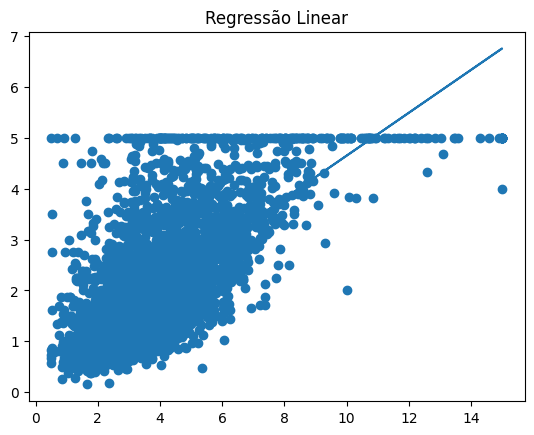

MSE Polinomial: 0.7120211880403858
CV Linear: 0.7231529493564786
CV Polinomial: 0.7074069193845445


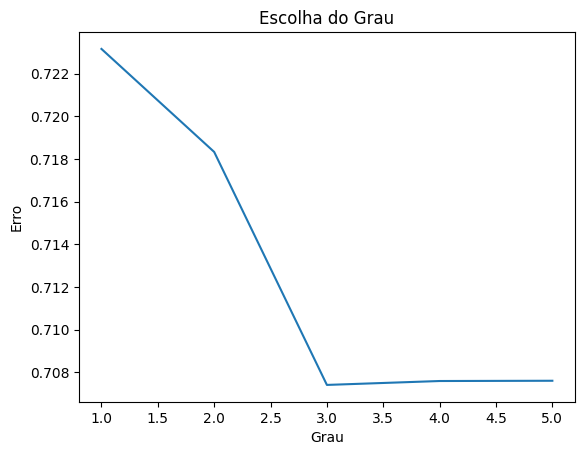

In [1]:
# ==============================
# IMPORTS
# ==============================
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error

# ==============================
# DATASET
# ==============================
data = fetch_california_housing()
X = data.data[:, 0].reshape(-1,1)  # renda média
y = data.target
# ==============================
# ==============================
# SPLIT
# ==============================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# ==============================
# REGRESSÃO LINEAR
# ==============================
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

pred = lin_model.predict(X_test)
print("MSE Linear:", mean_squared_error(y_test, pred))

# ==============================
# GRÁFICO
# ==============================
plt.scatter(X_test, y_test)
plt.plot(X_test, pred)
plt.title("Regressão Linear")
plt.show()

# ==============================
# POLINOMIAL
# ==============================
poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=3)),
    ("lin", LinearRegression())
])

poly_model.fit(X_train, y_train)
pred_poly = poly_model.predict(X_test)

print("MSE Polinomial:", mean_squared_error(y_test, pred_poly))

# ==============================
# VALIDAÇÃO CRUZADA
# ==============================
scores = cross_val_score(lin_model, X, y, cv=5, scoring="neg_mean_squared_error")
print("CV Linear:", -scores.mean())

scores_poly = cross_val_score(poly_model, X, y, cv=5, scoring="neg_mean_squared_error")
print("CV Polinomial:", -scores_poly.mean())

# ==============================
# COMPARAÇÃO DE GRAUS
# ==============================
degrees = [1,2,3,4,5]
errors = []

for d in degrees:
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=d)),
        ("lin", LinearRegression())
    ])
    score = -cross_val_score(model, X, y, cv=5,
                             scoring="neg_mean_squared_error").mean()
    errors.append(score)

plt.plot(degrees, errors)
plt.xlabel("Grau")
plt.ylabel("Erro")
plt.title("Escolha do Grau")
plt.show()

In [4]:
import pandas as pd 
import numpy as np 

train_dataset = pd.read_csv('/home/nes_pedro/FUND-IA/DATABASES/dadosprecocivic.csv', sep=';')
display(train_dataset['kilometragem-x'])

X = train_dataset['kilometragem-x']
Y = train_dataset['preco-y']

mediaX = np.mean(X)
mediaY = np.mean(Y)

stdX = np.std(X, ddof=1)
stdY = np.std(Y, ddof=1)

print("Media X %d", mediaX)
print("Media Y %d", mediaY)
print("Desvio Padrao X %d", stdX)
print("Desvio Padrao Y %d", stdY)

deviationX = X - mediaX
deviationY = Y - mediaY

sumCovariance = np.sum(deviationX * deviationY)
print("Soma da Covariancia %d", sumCovariance)

N = train_dataset.shape[0]
print(N)

pearsonCorrelation = sumCovariance / ((N-1) * stdX * stdY)
print("Correlacao %.4f", pearsonCorrelation)

beta  = pearsonCorrelation * (stdY / stdX)
alpha = mediaY - (beta * mediaX)
print("Beta %d",  beta)
print("Alpha %d", alpha)


0       9300
1      10565
2      15000
3      15000
4      17764
5      57000
6      65940
7      73676
8      77006
9      93739
10    146088
11    153260
Name: kilometragem-x, dtype: int64

Media X %d 61194.833333333336
Media Y %d 4998.75
Desvio Padrao X %d 50988.830753470516
Desvio Padrao Y %d 4078.5158424692586
Soma da Covariancia %d -1466216047.5
12
Correlacao %.4f -0.6409557923377475
Beta %d -0.05126903901780507
Alpha %d 8136.150297854745


0       9300
1      10565
2      15000
3      15000
4      17764
5      57000
6      65940
7      73676
8      77006
9      93739
10    146088
11    153260
Name: kilometragem-x, dtype: int64

Inclinação (Beta): -0.0513
Intercepto (Alpha): 8136.1503
Pearson (r): -0.6410
R² (Poder de explicação): 0.4108


NameError: name 'intercept' is not defined

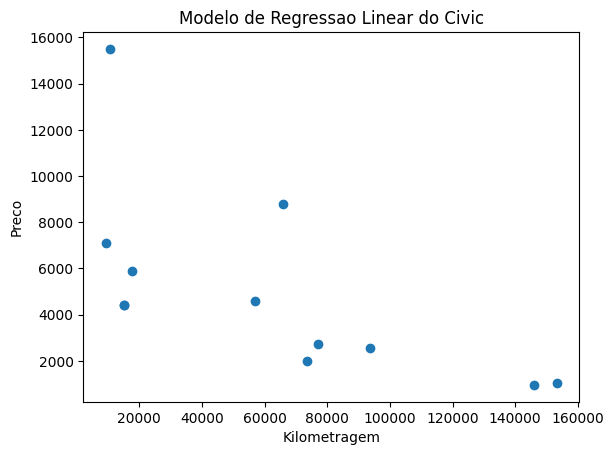

In [ ]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

train_dataset = pd.read_csv('/home/nes_pedro/FUND-IA/DATABASES/dadosprecocivic.csv', sep=';')
display(train_dataset['kilometragem-x'])

X = train_dataset['kilometragem-x']
Y = train_dataset['preco-y']

beta, alpha, pearson, p_value, std_err = stats.linregress(X, Y)
erroquadratico = pearson ** 2

print(f"Inclinação (Beta): {beta:.4f}")
print(f"Intercepto (Alpha): {alpha:.4f}")
print(f"Pearson (r): {pearson:.4f}")
print(f"R² (Poder de explicação): {erroquadratico:.4f}")

plt.title('Modelo de Regressao Linear do Civic')
plt.xlabel('Kilometragem')
plt.ylabel('Preco')
plt.plot(X, Y, 'o', label = 'original data')
plt.plot(X, intercept + slope*X , 'r', label='fitted line')
plt.legend()
plt.show()